# 01 — Análisis Exploratorio de Datos

## Modelación Predictiva de la Siniestralidad en Seguros de Automóviles

**Seminario investigativo — Ciencia de Datos aplicada al sector asegurador**

---

### 1. Introducción

**Objetivo del notebook.** Este notebook realiza el primer acercamiento exploratorio y
riguroso a los datos que soportarán la investigación sobre modelación predictiva de la
siniestralidad en seguros de automóviles. El propósito es **describir** la información
disponible —su estructura, calidad y comportamiento general— sin todavía construir,
ajustar ni evaluar ningún modelo predictivo.

**Contexto actuarial.** En seguros de responsabilidad civil de automóviles (*Motor
Third-Party Liability*, MTPL), la prima de riesgo de una póliza suele descomponerse como:

$$
\text{Prima pura} \approx \text{Frecuencia} \times \text{Severidad}
$$

- **Frecuencia**: número esperado de siniestros por unidad de exposición al riesgo.
- **Severidad**: costo monetario esperado de un siniestro, condicionado a que este ocurra.

Esta descomposición es la razón por la cual los datos se organizan en dos tablas
complementarias: una a nivel de póliza (para frecuencia) y otra a nivel de siniestro
(para severidad).

**Origen de los datos.** Se trabaja con el conjunto de datos público **freMTPL2**,
correspondiente a una cartera de pólizas de responsabilidad civil de automóviles en
Francia, observadas durante un período de aproximadamente un año. Este conjunto ha sido
ampliamente utilizado en la literatura actuarial y de aprendizaje automático aplicado a
seguros (Charpentier, *Computational Actuarial Science with R*, CRC Press; también
distribuido a través de OpenML con `data_id=41214` para la tabla de frecuencia y
`data_id=41215` para la tabla de severidad).

> **Nota sobre la tabla de severidad (`freMTPL2sev.csv`).** La versión de la tabla de
> severidad utilizada en este proyecto contiene el **monto total de siniestros agregado
> por póliza** (`IDpol`, `ClaimAmount`), derivado de la fuente pública verificada. La
> tabla de severidad original de `CASdatasets` registra cada siniestro de forma
> individual (una póliza con varios siniestros puede tener varias filas). Este notebook
> documenta explícitamente esta diferencia en la Sección 11 y ajusta la interpretación de
> los resultados en consecuencia. No se ha inventado ni simulado ningún monto: los valores
> provienen íntegramente de la fuente original.

**Propósito del EDA dentro de la investigación.** Este análisis exploratorio busca:
1. Verificar la calidad estructural de los datos (dimensiones, tipos, duplicados, nulos).
2. Caracterizar de forma general las variables disponibles para frecuencia y severidad.
3. Detectar —sin corregir todavía— posibles inconsistencias que deberán abordarse en una
   etapa posterior de preprocesamiento.
4. Sentar las bases para el análisis univariado (Notebook 02) y, más adelante, para el
   análisis bivariado/multivariado y la modelación (GLM, Machine Learning, redes
   neuronales), que quedan explícitamente **fuera del alcance** de este notebook.


### 2. Importación de librerías

Se importan únicamente las librerías necesarias para el análisis exploratorio y descriptivo: `pandas` y `numpy` para manipulación de datos, `matplotlib` y `seaborn` para visualización, y `scipy.stats` para el cálculo puntual de asimetría. No se importan librerías de modelación en esta etapa.

In [4]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Permite importar las funciones auxiliares definidas en src/utils.py
sys.path.append(str(Path("..").resolve()))
from src.utils import (
    set_plot_style, load_freq, load_sev,
    resumen_numerico, tabla_frecuencias, resumen_categorico,
    hist_box, barplot_top_categorias,
)

set_plot_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42  # fijado por reproducibilidad, aunque en este notebook no se muestrea

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


### 3. Carga de datos

Se cargan las dos tablas del conjunto `freMTPL2` desde `data/raw/` mediante rutas
relativas robustas (ver `src/utils.py::get_data_path`), de forma que el notebook funcione
tanto de forma local (VS Code, Jupyter) como en un entorno de despliegue o en Google
Colab (ajustando únicamente la ruta base si fuese necesario).

- `freMTPL2freq.csv`: variables de riesgo y número de siniestros por póliza.
- `freMTPL2sev.csv`: monto total de siniestros agregado por póliza (ver nota de la
  introducción sobre la naturaleza agregada de esta tabla).


In [5]:
df_freq = load_freq("freMTPL2freq.csv")
df_sev = load_sev("freMTPL2sev.csv")

print(f"freMTPL2freq: {df_freq.shape[0]:,} filas x {df_freq.shape[1]} columnas")
print(f"freMTPL2sev : {df_sev.shape[0]:,} filas x {df_sev.shape[1]} columnas")


freMTPL2freq: 678,007 filas x 12 columnas
freMTPL2sev : 24,938 filas x 2 columnas


### 4. Inspección inicial

Se examinan dimensiones, primeras y últimas observaciones, nombres de columnas, tipos de datos y uso de memoria de ambas tablas.

In [6]:
print("Dimensiones freMTPL2freq:", df_freq.shape)
print("Dimensiones freMTPL2sev :", df_sev.shape)


Dimensiones freMTPL2freq: (678007, 12)
Dimensiones freMTPL2sev : (24938, 2)


In [7]:
df_freq.head()

,IDpol,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimNb
0,1,0.1000,D,5,0,55,50,B12,Regular,1217,R82,0
1,3,0.7700,D,5,0,55,50,B12,Regular,1217,R82,0
2,5,0.7500,B,6,2,52,50,B12,Diesel,54,R22,0
3,10,0.0900,B,7,0,46,50,B12,Diesel,76,R72,0
4,11,0.8400,B,7,0,46,50,B12,Diesel,76,R72,0


In [8]:
df_freq.tail()

,IDpol,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimNb
678002,6114326,0.0027,E,4,0,54,50,B12,Regular,3317,R93,0
678003,6114327,0.0027,E,4,0,41,95,B12,Regular,9850,R11,0
678004,6114328,0.0027,D,6,2,45,50,B12,Diesel,1323,R82,0
678005,6114329,0.0027,B,4,0,60,50,B12,Regular,95,R26,0
678006,6114330,0.0027,B,7,6,29,54,B12,Diesel,65,R72,0


In [9]:
df_sev.head()

,IDpol,ClaimAmount
0,139,303.0000
1,190,"1,981.8400"
2,414,"1,456.5500"
3,424,"10,834.0000"
4,463,"3,986.6700"


In [10]:
df_sev.tail()

,IDpol,ClaimAmount
24933,6113521,"1,324.4000"
24934,6113793,"1,769.8800"
24935,6113817,"1,288.2800"
24936,6113834,"12,230.4000"
24937,6113971,"1,452.0000"


In [11]:
print("Columnas freMTPL2freq:", list(df_freq.columns))
print("Columnas freMTPL2sev :", list(df_sev.columns))


Columnas freMTPL2freq: ['IDpol', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region', 'ClaimNb']
Columnas freMTPL2sev : ['IDpol', 'ClaimAmount']


In [12]:
df_freq.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 678007 entries, 0 to 678006
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678007 non-null  int64  
 1   Exposure    678007 non-null  float64
 2   Area        678007 non-null  object 
 3   VehPower    678007 non-null  int64  
 4   VehAge      678007 non-null  int64  
 5   DrivAge     678007 non-null  int64  
 6   BonusMalus  678007 non-null  int64  
 7   VehBrand    678007 non-null  object 
 8   VehGas      678007 non-null  object 
 9   Density     678007 non-null  int64  
 10  Region      678007 non-null  object 
 11  ClaimNb     678007 non-null  int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 197.1 MB


In [13]:
df_sev.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24938 entries, 0 to 24937
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   IDpol        24938 non-null  int64  
 1   ClaimAmount  24938 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 389.8 KB


**Interpretación.** `freMTPL2freq` contiene 678.007 pólizas (una fila por póliza)
con 12 columnas: el identificador `IDpol`, la variable de exposición al riesgo
`Exposure`, ocho variables de riesgo del vehículo y del conductor (`Area`, `VehPower`,
`VehAge`, `DrivAge`, `BonusMalus`, `VehBrand`, `VehGas`, `Density`, `Region`) y la
variable objetivo de frecuencia `ClaimNb`. `freMTPL2sev` contiene 24.938 registros con
dos columnas (`IDpol`, `ClaimAmount`), correspondientes a las pólizas que presentaron al
menos un siniestro con monto positivo. Ninguna de las dos tablas presenta valores nulos
declarados a nivel de columna (se profundiza en la Sección 12).

### 5. Estructura de las bases

Se clasifican las variables según su naturaleza para orientar el resto del análisis.
Esta clasificación es descriptiva y no implica ninguna decisión de modelación.


In [14]:
clasificacion_freq = pd.DataFrame({
    "variable": df_freq.columns,
    "dtype": df_freq.dtypes.astype(str).values,
    "tipo_conceptual": [
        "Identificador de póliza",           # IDpol
        "Numérica continua (exposición)",    # Exposure
        "Categórica (código de área)",       # Area
        "Numérica discreta/ordinal",         # VehPower
        "Numérica discreta",                 # VehAge
        "Numérica discreta",                 # DrivAge
        "Numérica discreta",                 # BonusMalus
        "Categórica (marca)",                # VehBrand
        "Categórica (tipo de combustible)",  # VehGas
        "Numérica continua",                 # Density
        "Categórica (región)",               # Region
        "Numérica discreta (variable objetivo frecuencia)",  # ClaimNb
    ],
})
clasificacion_freq


,variable,dtype,tipo_conceptual
0,IDpol,int64,Identificador de póliza
1,Exposure,float64,Numérica continua (exposición)
2,Area,object,Categórica (código de área)
3,VehPower,int64,Numérica discreta/ordinal
4,VehAge,int64,Numérica discreta
5,DrivAge,int64,Numérica discreta
6,BonusMalus,int64,Numérica discreta
7,VehBrand,object,Categórica (marca)
8,VehGas,object,Categórica (tipo de combustible)
9,Density,int64,Numérica continua


In [15]:
clasificacion_sev = pd.DataFrame({
    "variable": df_sev.columns,
    "dtype": df_sev.dtypes.astype(str).values,
    "tipo_conceptual": [
        "Identificador de póliza (llave de relación con freMTPL2freq)",
        "Numérica continua (variable objetivo severidad)",
    ],
})
clasificacion_sev


,variable,dtype,tipo_conceptual
0,IDpol,int64,Identificador de póliza (llave de relación con...
1,ClaimAmount,float64,Numérica continua (variable objetivo severidad)


**Interpretación.** `freMTPL2freq` combina un identificador (`IDpol`), variables
numéricas discretas y continuas relacionadas con el vehículo y el conductor, y variables
categóricas de tipo geográfico y comercial. `freMTPL2sev` tiene una estructura mucho más
simple: únicamente el identificador de póliza y el monto de siniestro, lo cual es
consistente con su rol de tabla "larga" orientada al costo de los siniestros, en
contraste con la tabla "ancha" de riesgo que es `freMTPL2freq`.

### 6. Estadística descriptiva inicial

Se presentan estadísticas descriptivas (conteo, media, desviación estándar, mínimo,
percentiles, mediana, máximo) para las variables numéricas, y frecuencias absolutas y
relativas para las variables categóricas.


In [16]:
num_cols_freq = ["Exposure", "VehPower", "VehAge", "DrivAge", "BonusMalus", "Density", "ClaimNb"]
resumen_numerico(df_freq, num_cols_freq)


,count,mean,std,min,1%,25%,50%,75%,99%,max,skew,missing,missing_%
Exposure,"678,007.0000",0.5290,0.3640,0.0030,0.0080,0.1800,0.4900,0.9900,1.0000,1.0000,0.0820,0,0.0000
VehPower,"678,007.0000",6.4550,2.0510,4.0000,4.0000,5.0000,6.0000,7.0000,13.0000,15.0000,1.1710,0,0.0000
VehAge,"678,007.0000",7.0440,5.6660,0.0000,0.0000,2.0000,6.0000,11.0000,21.0000,100.0000,1.1480,0,0.0000
DrivAge,"678,007.0000",45.4990,14.1370,18.0000,20.0000,34.0000,44.0000,55.0000,80.0000,100.0000,0.4360,0,0.0000
BonusMalus,"678,007.0000",59.7620,15.6370,50.0000,50.0000,50.0000,50.0000,64.0000,106.0000,230.0000,1.7290,0,0.0000
Density,"678,007.0000","1,792.4310","3,958.6630",1.0000,10.0000,92.0000,393.0000,"1,658.0000","27,000.0000","27,000.0000",4.6510,0,0.0000
ClaimNb,"678,007.0000",0.0390,0.2050,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,5.0000,5.6430,0,0.0000


In [17]:
resumen_numerico(df_sev, ["ClaimAmount"])

,count,mean,std,min,1%,25%,50%,75%,99%,max,skew,missing,missing_%
ClaimAmount,"24,938.0000","2,397.0480","30,266.6190",1.0000,39.8750,749.2620,"1,172.0000","1,346.3600","17,960.2370","4,075,400.5600",106.1510,0,0.0000


In [18]:
cat_cols_freq = ["Area", "VehBrand", "VehGas", "Region"]
resumen_categorico(df_freq, cat_cols_freq)


,n_categorias,categoria_dominante,peso_categoria_dominante_%,categoria_menos_frecuente,peso_categoria_menos_frecuente_%
variable,,,,,
Area,6,C,28.3000,F,2.6481
VehBrand,11,B12,24.4900,B14,0.5969
VehGas,2,Regular,51.0100,Diesel,48.9871
Region,22,R24,23.6900,R43,0.1956


**Interpretación.** Las variables numéricas de `freMTPL2freq` muestran escalas muy
distintas entre sí (p. ej. `Exposure` está acotada en [0, 1], mientras que `Density`
alcanza miles de habitantes por km²), lo que deberá considerarse en etapas posteriores de
modelación pero no se corrige aquí. Entre las variables categóricas, `VehGas` es binaria,
mientras que `Region` y `VehBrand` presentan mayor cardinalidad; `Area` se mantiene
acotada a 6 categorías. La variable `ClaimAmount` (severidad) presenta, como es habitual
en montos de siniestros, una media claramente superior a la mediana, lo que sugiere una
distribución con cola derecha pesada — se profundiza en la Sección 10.

### 7. Variables numéricas

Esta sección ofrece un panorama general de las variables numéricas de `freMTPL2freq` y
`freMTPL2sev`. El análisis detallado, variable por variable, con interpretación
actuarial específica, se desarrolla en el **Notebook 02 — Análisis Univariado**, que es
el instrumento diseñado específicamente para ese propósito.


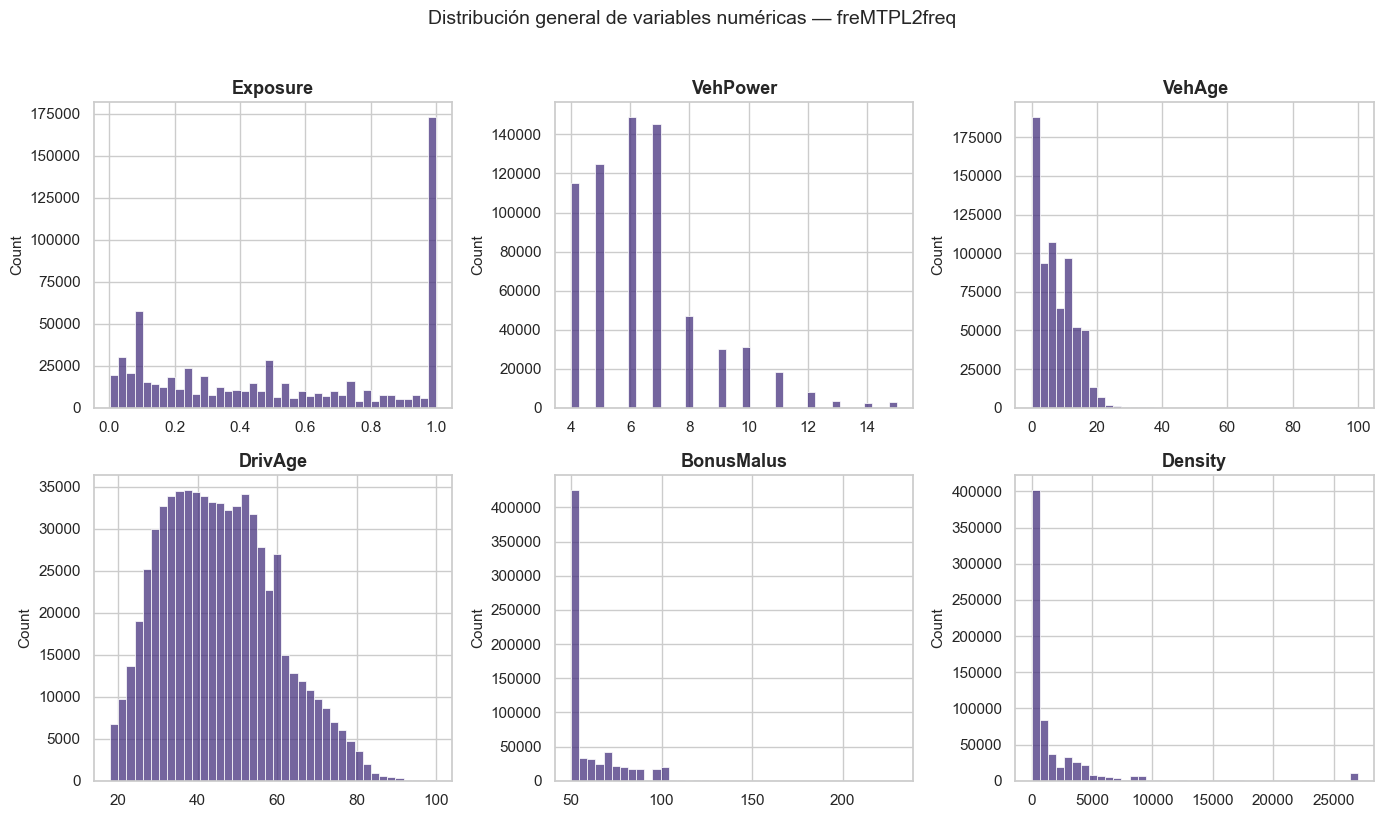

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), ["Exposure", "VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]):
    sns.histplot(df_freq[col], bins=40, ax=ax, kde=False)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Distribución general de variables numéricas — freMTPL2freq", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


**Interpretación general.** `Exposure`, `VehAge`, `DrivAge` y `BonusMalus` muestran
formas de distribución relativamente reconocibles (acotada, decreciente, aproximadamente
unimodal y muy concentrada en el valor mínimo, respectivamente), mientras que `Density`
y `VehPower` muestran mayor concentración en valores bajos con colas más largas hacia
la derecha. Un análisis detallado de cada una se realiza en el Notebook 02.

### 8. Variables categóricas

Se examina la cardinalidad y el desbalance de las variables categóricas presentes:
`Area`, `VehBrand`, `VehGas` y `Region`. Para variables con muchas categorías se
muestran únicamente las más frecuentes (*top-N*), indicándolo explícitamente.


In [20]:
tabla_frecuencias(df_freq, "Area")

,frecuencia_absoluta,frecuencia_relativa_%
Area,,
C,191880,28.3000
D,151590,22.3600
E,137167,20.2300
A,103957,15.3300
B,75459,11.1300
F,17954,2.6500


In [21]:
tabla_frecuencias(df_freq, "VehGas")

,frecuencia_absoluta,frecuencia_relativa_%
VehGas,,
Regular,345871,51.0100
Diesel,332136,48.9900


In [22]:
print(f"VehBrand tiene {df_freq['VehBrand'].nunique()} categorías. Se muestran las 11 disponibles (no se recorta):")
tabla_frecuencias(df_freq, "VehBrand")


VehBrand tiene 11 categorías. Se muestran las 11 disponibles (no se recorta):


,frecuencia_absoluta,frecuencia_relativa_%
VehBrand,,
B12,166024,24.4900
B1,162730,24.0000
B2,159861,23.5800
B3,53395,7.8800
B5,34753,5.1300
B6,28548,4.2100
B4,25179,3.7100
B10,17707,2.6100
B11,13585,2.0000


In [23]:
print(f"Region tiene {df_freq['Region'].nunique()} categorías. Se muestran únicamente las 10 más frecuentes (top-10):")
tabla_frecuencias(df_freq, "Region", top_n=10)


Region tiene 22 categorías. Se muestran únicamente las 10 más frecuentes (top-10):


,frecuencia_absoluta,frecuencia_relativa_%
Region,,
R24,160601,23.6900
R82,84752,12.5000
R93,79315,11.7000
R11,69791,10.2900
R53,42122,6.2100
R52,38751,5.7200
R91,35799,5.2800
R72,31329,4.6200
R31,27285,4.0200


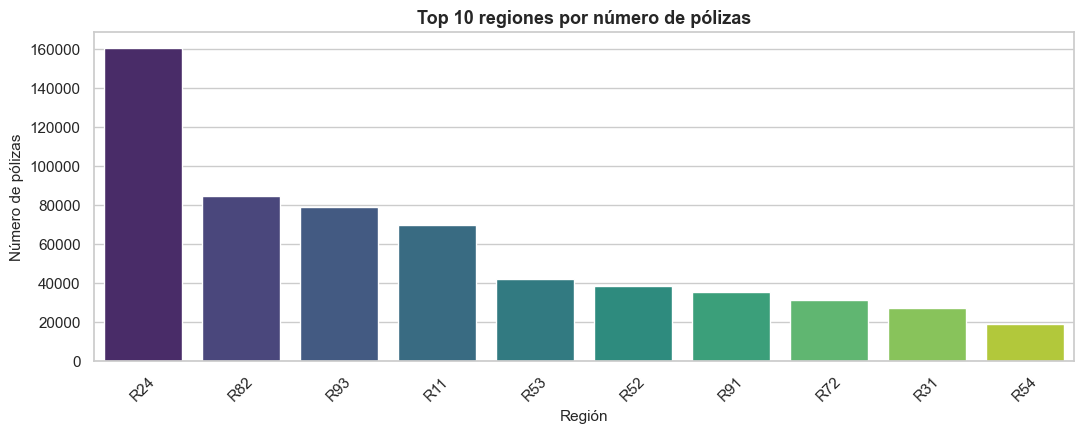

In [24]:
barplot_top_categorias(df_freq, "Region", top_n=10,
                       titulo="Top 10 regiones por número de pólizas",
                       xlabel="Región")


**Interpretación.** `Area` (6 categorías) y `VehGas` (2 categorías) presentan baja
cardinalidad y se pueden analizar de forma completa sin necesidad de agrupación.
`VehBrand` (11 categorías) es manejable en su totalidad. `Region` (22 categorías)
requiere un recorte a las categorías más frecuentes para efectos de visualización, aunque
el análisis tabular sí contempla la totalidad de las categorías. Se observa una
concentración moderada de pólizas en un subconjunto reducido de regiones, lo cual podría
ser relevante posteriormente para la modelación de frecuencia por su asociación
geográfica con la densidad poblacional y el riesgo de siniestro.

### 9. Identificación de variables relacionadas con frecuencia

Se exploran `ClaimNb` (número de siniestros por póliza) y `Exposure` (duración de la
observación de la póliza, en años), variables centrales para la futura modelación de
frecuencia. Este análisis es descriptivo: no se ajusta ningún modelo de frecuencia en
esta etapa.


In [25]:
conteo_claimnb = df_freq["ClaimNb"].value_counts().sort_index()
proporcion_claimnb = (conteo_claimnb / len(df_freq) * 100).round(3)
pd.DataFrame({"n_polizas": conteo_claimnb, "%_del_total": proporcion_claimnb})


,n_polizas,%_del_total
ClaimNb,,
0,653069,96.3220
1,23571,3.4770
2,1298,0.1910
3,62,0.0090
4,5,0.0010
5,2,0.0000


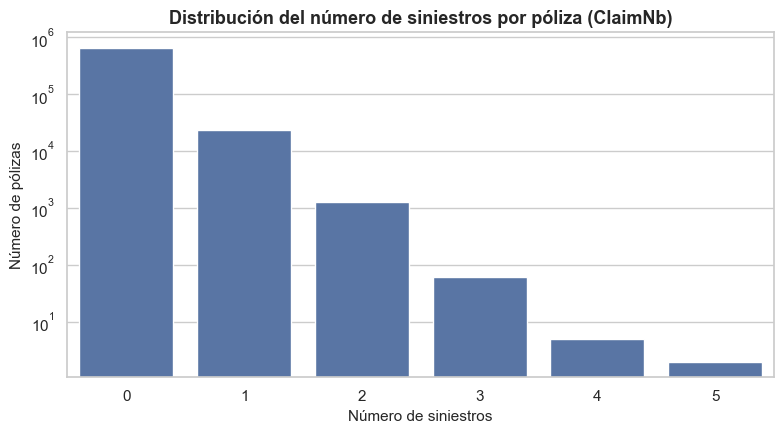

In [26]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=conteo_claimnb.index, y=conteo_claimnb.values, ax=ax, color="#4C72B0")
ax.set_title("Distribución del número de siniestros por póliza (ClaimNb)")
ax.set_xlabel("Número de siniestros")
ax.set_ylabel("Número de pólizas")
ax.set_yscale("log")
plt.tight_layout()
plt.show()


In [27]:
exposure_media = df_freq["Exposure"].mean()
frecuencia_global = df_freq["ClaimNb"].sum() / df_freq["Exposure"].sum()
print(f"Exposición promedio por póliza: {exposure_media:.4f} años")
print(f"Suma total de siniestros:      {df_freq['ClaimNb'].sum():,}")
print(f"Suma total de exposición:      {df_freq['Exposure'].sum():,.2f} años-póliza")
print(f"Frecuencia empírica global (ClaimNb / Exposure): {frecuencia_global:.4f} siniestros por año-póliza")


Exposición promedio por póliza: 0.5285 años
Suma total de siniestros:      26,383
Suma total de exposición:      358,358.81 años-póliza
Frecuencia empírica global (ClaimNb / Exposure): 0.0736 siniestros por año-póliza


**Interpretación.** La gran mayoría de las pólizas (más del 96%) no reportan
ningún siniestro durante el período observado, lo cual es característico de los datos
de frecuencia en seguros de automóviles y anticipa la necesidad de modelos que asuman
distribuciones de conteo (p. ej. Poisson) en etapas posteriores. La exposición (`Exposure`)
actúa como el denominador natural de la frecuencia: dos pólizas con el mismo número de
siniestros pero exposiciones distintas representan niveles de riesgo muy diferentes por
unidad de tiempo. Esta relación —número de siniestros ponderado por exposición— será la
base conceptual de la futura modelación de frecuencia, aunque aquí únicamente se describe.

### 10. Exploración inicial de severidad

Se explora `ClaimAmount` de la tabla `freMTPL2sev`. Los montos de siniestros suelen
presentar distribuciones altamente asimétricas, por lo que se examinan media, mediana,
percentiles, rango y asimetría, y se utiliza una escala logarítmica **únicamente con
fines de visualización exploratoria** (no se transforma la variable para modelarla en
esta etapa).


In [28]:
claim_amount = df_sev["ClaimAmount"]
resumen_sev = claim_amount.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.9, 0.99])
asimetria_sev = stats.skew(claim_amount)

print(resumen_sev)
print(f"\nAsimetría (skewness): {asimetria_sev:.2f}")
print(f"Rango: {claim_amount.max() - claim_amount.min():,.2f}")


count      24,938.0000
mean        2,397.0479
std        30,266.6188
min             1.0000
1%             39.8751
25%           749.2625
50%         1,172.0000
75%         1,346.3600
90%         2,996.2370
99%        17,960.2374
max     4,075,400.5600
Name: ClaimAmount, dtype: float64

Asimetría (skewness): 106.14
Rango: 4,075,399.56


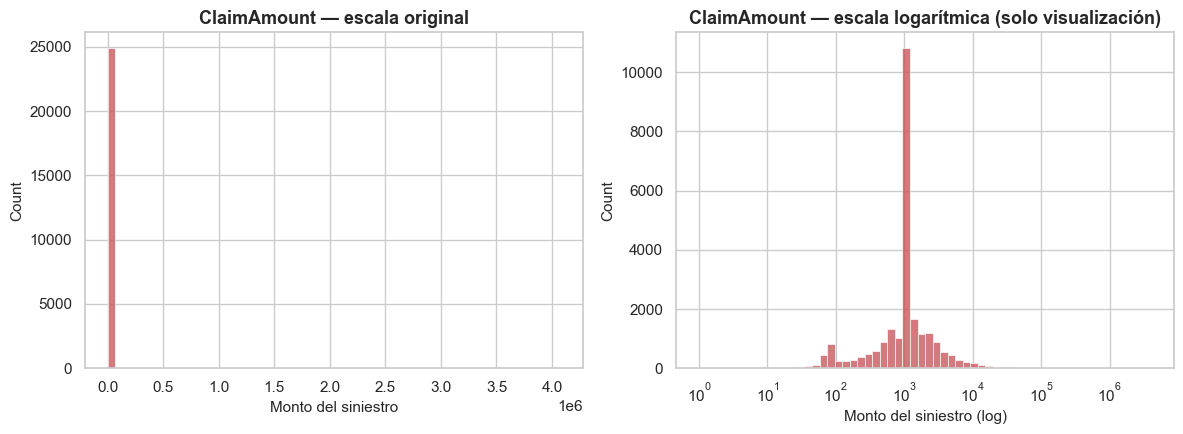

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(claim_amount, bins=60, ax=axes[0], color="#C44E52")
axes[0].set_title("ClaimAmount — escala original")
axes[0].set_xlabel("Monto del siniestro")

sns.histplot(claim_amount, bins=60, ax=axes[1], color="#C44E52", log_scale=True)
axes[1].set_title("ClaimAmount — escala logarítmica (solo visualización)")
axes[1].set_xlabel("Monto del siniestro (log)")

plt.tight_layout()
plt.show()


In [30]:
top_10_claims = claim_amount.sort_values(ascending=False).head(10)
print("10 montos de siniestro más altos registrados:")
print(top_10_claims.to_string())
print(f"\nEstos 10 registros representan el "
      f"{top_10_claims.sum() / claim_amount.sum() * 100:.2f}% del monto total de siniestros.")


10 montos de siniestro más altos registrados:
7487    4,075,400.5600
2842    1,404,185.5200
12729   1,301,172.6000
17079     774,411.5000
9764      399,213.6600
15349     382,955.1400
7357      307,096.4200
3800      301,635.4900
16177     287,423.0000
17784     281,897.4900

Estos 10 registros representan el 15.92% del monto total de siniestros.


**Interpretación.** La media de `ClaimAmount` es considerablemente mayor que la
mediana, y el coeficiente de asimetría es marcadamente positivo, lo cual confirma una
distribución con cola derecha muy pesada: la mayoría de los siniestros son de monto
moderado, pero una minoría de siniestros extremos concentra una proporción relevante del
costo total. Este patrón es característico de la severidad en seguros y sugiere que, en
etapas posteriores, será necesario evaluar distribuciones específicas para variables
continuas positivas y asimétricas (p. ej. Gamma, Log-Normal) — sin que esto implique
ninguna decisión de modelación en este notebook. La escala logarítmica utilizada arriba
es exclusivamente una herramienta de visualización exploratoria.

### 11. Relación estructural entre tablas

Se analiza cómo se relacionan `freMTPL2freq` y `freMTPL2sev` a través de la llave común
`IDpol`, sin construir todavía el dataset definitivo de modelación (esa tarea
corresponde a una etapa posterior de preprocesamiento).


In [31]:
n_polizas = df_freq["IDpol"].nunique()
n_polizas_con_siniestro_segun_freq = (df_freq["ClaimNb"] > 0).sum()
n_polizas_con_registro_en_sev = df_sev["IDpol"].nunique()
n_registros_sev = len(df_sev)
duplicados_idpol_sev = df_sev["IDpol"].duplicated().sum()
duplicados_idpol_freq = df_freq["IDpol"].duplicated().sum()

resumen_relacion = pd.DataFrame({
    "métrica": [
        "Pólizas únicas en freMTPL2freq",
        "Pólizas con ClaimNb > 0 (según freMTPL2freq)",
        "Pólizas únicas presentes en freMTPL2sev",
        "Registros totales en freMTPL2sev",
        "IDpol duplicados en freMTPL2freq",
        "IDpol duplicados en freMTPL2sev",
    ],
    "valor": [
        n_polizas, n_polizas_con_siniestro_segun_freq,
        n_polizas_con_registro_en_sev, n_registros_sev,
        duplicados_idpol_freq, duplicados_idpol_sev,
    ],
})
resumen_relacion


,métrica,valor
0,Pólizas únicas en freMTPL2freq,678007
1,Pólizas con ClaimNb > 0 (según freMTPL2freq),24938
2,Pólizas únicas presentes en freMTPL2sev,24938
3,Registros totales en freMTPL2sev,24938
4,IDpol duplicados en freMTPL2freq,0
5,IDpol duplicados en freMTPL2sev,0


In [32]:
ids_freq = set(df_freq["IDpol"])
ids_sev = set(df_sev["IDpol"])

en_sev_no_en_freq = ids_sev - ids_freq
en_freq_con_claimnb_pero_no_en_sev = {
    idpol for idpol in df_freq.loc[df_freq["ClaimNb"] > 0, "IDpol"] if idpol not in ids_sev
}

print(f"IDpol en freMTPL2sev que NO existen en freMTPL2freq: {len(en_sev_no_en_freq)}")
print(f"Pólizas con ClaimNb > 0 en freMTPL2freq que NO tienen registro en freMTPL2sev: "
      f"{len(en_freq_con_claimnb_pero_no_en_sev)}")


IDpol en freMTPL2sev que NO existen en freMTPL2freq: 0
Pólizas con ClaimNb > 0 en freMTPL2freq que NO tienen registro en freMTPL2sev: 0


**Interpretación.** La llave de relación entre ambas tablas es `IDpol`. No se
identifican valores duplicados de `IDpol` dentro de `freMTPL2freq` (una fila por
póliza). Es importante señalar que, en la tabla oficial `freMTPL2sev` de `CASdatasets`,
cada fila representa un siniestro individual, por lo que una póliza con varios siniestros
puede aparecer en varias filas (y por tanto sí podrían existir `IDpol` duplicados en esa
versión). **La versión de `freMTPL2sev.csv` utilizada en este proyecto ya se encuentra
agregada a nivel de póliza** (un `IDpol` = un monto total de siniestros), por lo que no
se observan duplicados en `df_sev`. Esta diferencia se documenta aquí de forma explícita
para que sea considerada en cualquier análisis posterior que dependa de la multiplicidad
de siniestros por póliza (por ejemplo, un análisis fino de severidad por evento individual
requeriría obtener la tabla `freMTPL2sev` oficial sin agregar, tal como se indica en el
`README.md` del proyecto). El cruce de identificadores no muestra pólizas de `freMTPL2sev`
ausentes en `freMTPL2freq`, lo que es consistente con una relación de integridad
referencial adecuada entre ambas tablas.

### 12. Diagnóstico exploratorio de consistencia

Se realiza una primera inspección de valores potencialmente problemáticos. **Importante:**
en esta etapa únicamente se detectan, cuantifican y documentan estos valores; **no se
corrigen, imputan ni eliminan registros**. El tratamiento de estos hallazgos corresponde
a una etapa posterior de validación y preprocesamiento.


In [33]:
diagnosticos = []

def registrar(nombre, condicion):
    n = int(condicion.sum())
    diagnosticos.append({
        "chequeo": nombre,
        "n_registros": n,
        "%_del_total": round(n / len(df_freq) * 100, 4),
    })

registrar("Exposure < 0", df_freq["Exposure"] < 0)
registrar("Exposure > 1", df_freq["Exposure"] > 1)
registrar("VehAge < 0", df_freq["VehAge"] < 0)
registrar("VehAge > 50 (valor atípicamente alto)", df_freq["VehAge"] > 50)
registrar("DrivAge < 18 (edad mínima legal de conducción en Francia)", df_freq["DrivAge"] < 18)
registrar("DrivAge > 90 (valor atípicamente alto)", df_freq["DrivAge"] > 90)
registrar("VehPower <= 0", df_freq["VehPower"] <= 0)
registrar("BonusMalus < 50 (por debajo del mínimo legal típico)", df_freq["BonusMalus"] < 50)
registrar("BonusMalus > 150 (malus elevado)", df_freq["BonusMalus"] > 150)
registrar("Density > 20000 hab/km² (extremadamente alta)", df_freq["Density"] > 20000)

diagnostico_freq = pd.DataFrame(diagnosticos)
diagnostico_freq


,chequeo,n_registros,%_del_total
0,Exposure < 0,0,0.0000
1,Exposure > 1,0,0.0000
2,VehAge < 0,0,0.0000
3,VehAge > 50 (valor atípicamente alto),97,0.0143
4,DrivAge < 18 (edad mínima legal de conducción ...,0,0.0000
5,DrivAge > 90 (valor atípicamente alto),401,0.0591
6,VehPower <= 0,0,0.0000
7,BonusMalus < 50 (por debajo del mínimo legal t...,0,0.0000
8,BonusMalus > 150 (malus elevado),209,0.0308
9,Density > 20000 hab/km² (extremadamente alta),11302,1.6669


In [34]:
n_claimamount_no_positivo = int((df_sev["ClaimAmount"] <= 0).sum())
print(f"Registros con ClaimAmount <= 0 en freMTPL2sev: {n_claimamount_no_positivo} "
      f"({n_claimamount_no_positivo / len(df_sev) * 100:.4f}% del total)")


Registros con ClaimAmount <= 0 en freMTPL2sev: 0 (0.0000% del total)


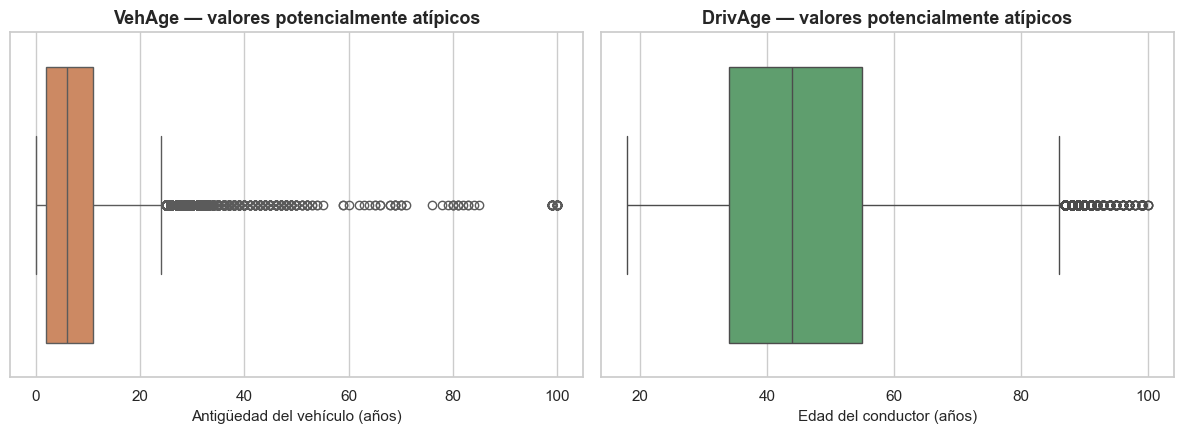

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(x=df_freq["VehAge"], ax=axes[0], color="#DD8452")
axes[0].set_title("VehAge — valores potencialmente atípicos")
axes[0].set_xlabel("Antigüedad del vehículo (años)")

sns.boxplot(x=df_freq["DrivAge"], ax=axes[1], color="#55A868")
axes[1].set_title("DrivAge — valores potencialmente atípicos")
axes[1].set_xlabel("Edad del conductor (años)")

plt.tight_layout()
plt.show()


**Interpretación.** `Exposure` se mantiene dentro del rango teórico esperado [0, 1]
en la totalidad de los registros, sin valores negativos ni superiores a 1. Se identifican,
sin embargo, valores de `VehAge` y `DrivAge` que se ubican en el extremo superior de la
distribución (por ejemplo, vehículos con antigüedad reportada de hasta 100 años y
conductores con edad reportada de hasta 100 años); si bien no son imposibles en términos
absolutos, ameritan una revisión de calidad de datos en una etapa posterior. `BonusMalus`
se mantiene mayormente dentro de rangos esperados, con una minoría de pólizas en el
extremo de malus elevado. `Density` presenta una cola derecha marcada, coherente con la
alta concentración poblacional de ciertas zonas urbanas francesas. No se detectan montos
de siniestro no positivos en `freMTPL2sev`. **Estos hallazgos quedan documentados para
ser abordados formalmente en la etapa de preprocesamiento; ningún registro se modifica ni
se elimina en este notebook.**

### 13. Visualizaciones exploratorias generales

Se presentan visualizaciones adicionales que aportan información no cubierta en las
secciones anteriores: relación entre variables numéricas y un mapa de correlaciones.


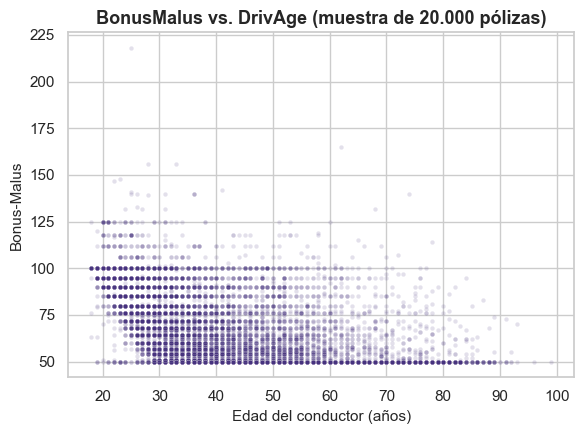

Nota: se utiliza una muestra de 20.000 pólizas únicamente para la legibilidad del gráfico de dispersión; los análisis estadísticos de este notebook se calculan sobre la totalidad de los datos.


In [36]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.scatterplot(
    data=df_freq.sample(20000, random_state=42),
    x="DrivAge", y="BonusMalus", alpha=0.15, s=10, ax=ax,
)
ax.set_title("BonusMalus vs. DrivAge (muestra de 20.000 pólizas)")
ax.set_xlabel("Edad del conductor (años)")
ax.set_ylabel("Bonus-Malus")
plt.tight_layout()
plt.show()
print("Nota: se utiliza una muestra de 20.000 pólizas únicamente para la legibilidad del "
      "gráfico de dispersión; los análisis estadísticos de este notebook se calculan "
      "sobre la totalidad de los datos.")


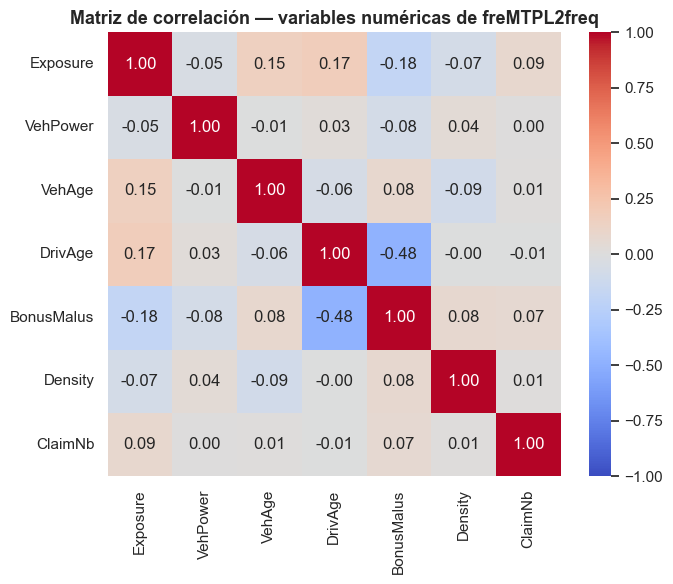

In [37]:
num_cols_corr = ["Exposure", "VehPower", "VehAge", "DrivAge", "BonusMalus", "Density", "ClaimNb"]
corr = df_freq[num_cols_corr].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Matriz de correlación — variables numéricas de freMTPL2freq")
plt.tight_layout()
plt.show()


**Interpretación.** El gráfico de dispersión entre `DrivAge` y `BonusMalus` sugiere
una posible asociación entre conductores jóvenes y niveles más altos de malus, coherente
con la lógica del sistema bonus-malus francés (los conductores con menor historial tienden
a iniciar en niveles de malus más altos). La matriz de correlación muestra, en general,
correlaciones lineales débiles entre las variables numéricas de riesgo y `ClaimNb`, lo
cual es esperable dado que `ClaimNb` es una variable de conteo con una relación
probablemente no lineal con sus predictores — una limitación conocida de la correlación
de Pearson para este tipo de variable, que deberá tenerse en cuenta al elegir métodos de
análisis bivariado en una etapa posterior. Estas observaciones son descriptivas y no
deben interpretarse como relaciones causales.

### 14. Hallazgos principales

1. `freMTPL2freq` contiene 678.007 pólizas sin valores nulos declarados, con 12
   variables que combinan información del vehículo, del conductor y del contexto
   geográfico de la póliza.
2. `freMTPL2sev` contiene 24.938 registros de monto de siniestro agregado por póliza;
   se documentó explícitamente que esta versión difiere de la tabla oficial no agregada
   de `CASdatasets` (ver Sección 11).
3. La frecuencia de siniestros es un fenómeno raro: más del 96% de las pólizas no
   reportan ningún siniestro en el período observado.
4. La severidad (`ClaimAmount`) presenta una distribución con asimetría positiva
   marcada, con una minoría de siniestros extremos que concentran una proporción
   relevante del costo total.
5. Se identificaron valores potencialmente atípicos en `VehAge` y `DrivAge` (extremo
   superior de sus rangos), que ameritan revisión en la etapa de preprocesamiento, sin
   que esto implique que se trate necesariamente de errores de captura.
6. `Exposure` se mantiene dentro del rango teórico [0, 1] en la totalidad de los
   registros analizados.
7. Las variables categóricas presentan cardinalidades manejables (`Area`, `VehGas`,
   `VehBrand`) o moderadas (`Region`), sin categorías extremadamente raras que impidan
   su análisis.

### 15. Conclusiones del EDA

Este análisis exploratorio confirma que los datos `freMTPL2` poseen una estructura
adecuada y suficientemente rica para sustentar la investigación planteada sobre
modelación predictiva de la siniestralidad. Se identificaron las variables candidatas a
explicar la frecuencia (`Exposure`, variables del vehículo y del conductor, variables
geográficas) y se caracterizó de forma preliminar el comportamiento de la severidad. Se
documentaron de forma transparente las particularidades y posibles limitaciones de los
datos (agregación de la tabla de severidad, valores atípicos en edades y antigüedades),
sin realizar ninguna corrección en esta etapa. El **Notebook 02 — Análisis Univariado**
profundiza el estudio variable por variable, y las etapas siguientes de la investigación
(análisis bivariado/multivariado, preprocesamiento y modelación) se apoyarán en los
hallazgos aquí documentados.
